# 07 - Model comparison

**Appliance energy forecasting**

**Inputs**

```text
outputs/forecasts/benchmark_forecasts_rolling.csv
outputs/forecasts/sarimax_forecasts_rolling.csv
outputs/forecasts/feature_forecasts_rolling.csv
outputs/forecasts/foundation_forecasts_rolling.csv
outputs/metrics/*_metrics_rolling.csv
outputs/metrics/foundation_run_details.csv
outputs/metrics/benchmark_mase_scale.csv
```

**Outputs produced**

```text
outputs/forecasts/all_forecasts.csv
outputs/forecasts/all_forecasts_extended.csv
outputs/metrics/model_comparison.csv
outputs/metrics/model_comparison_extended.csv
outputs/metrics/pairwise_significance.csv
outputs/figures/forecast_comparison.png
outputs/figures/error_diagnostics.png
outputs/figures/residual_acf.png
outputs/figures/07_mase_summary.png
```

## 1. Setup

In [1]:

# 1. Imports

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:

# 2. Configuration

def find_project_root(markers=("data/raw", "data/processed", "notebooks"), start=None):
    """
    Locate the project root by walking up from the working directory.

    The root is the first ancestor containing any of `markers`, so this works on
    a fresh setup (before data/processed exists) as well as later, and does not
    depend on the notebook folder having a particular name.
    """

    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if any((candidate / m).exists() for m in markers):
            return candidate

    raise FileNotFoundError(
        f"No project root found from {start} upwards.\n"
        f"Looked for: {markers}\n"
        "Expected layout:  <project>/notebooks/*.ipynb  and  <project>/data/raw/"
    )


PROJECT_ROOT = find_project_root()

OUTPUT_DIR = PROJECT_ROOT / "outputs"

FORECAST_DIR = OUTPUT_DIR / "forecasts"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURE_DIR = OUTPUT_DIR / "figures"

RANDOM_STATE = 0
rng = np.random.default_rng(RANDOM_STATE)

HORIZON = 24
TEST_STEPS = 14 * 24
N_WINDOWS = TEST_STEPS // HORIZON


def save_fig(fig, name, figure_dir=FIGURE_DIR):
    """Save a figure to outputs/figures and report the path."""

    path = figure_dir / name

    fig.savefig(path, dpi=200, bbox_inches="tight")

    print("Saved figure:", path)

    return path


print("Project root:", PROJECT_ROOT)

Project root: C:\Users\cjfin\Desktop\assignment 2


In [3]:

# 3. Load every forecast file

def load_forecasts(name):
    return pd.read_csv(FORECAST_DIR / name, index_col=0, parse_dates=True)


benchmark_rolling = load_forecasts("benchmark_forecasts_rolling.csv")
sarimax_rolling = load_forecasts("sarimax_forecasts_rolling.csv")
feature_rolling = load_forecasts("feature_forecasts_rolling.csv")
foundation_rolling = load_forecasts("foundation_forecasts_rolling.csv")

SCALE = float(
    pd.read_csv(METRICS_DIR / "benchmark_mase_scale.csv", index_col=0).loc["mase_scale", "value"]
)

actual = benchmark_rolling["actual"]

window = benchmark_rolling["window"].astype(int)
step = benchmark_rolling["step"].astype(int)

# Every file must describe the same test period.
for name, frame in [("sarimax", sarimax_rolling),
                    ("feature", feature_rolling),
                    ("foundation", foundation_rolling)]:
    assert frame.index.equals(actual.index), f"{name} index does not match"
    assert np.allclose(frame["actual"].values, actual.values), f"{name} actuals differ"

print("All four forecast files agree on the test period.")
print("Test period:", actual.index.min(), "to", actual.index.max())
print("Observations:", len(actual), "| Windows:", window.nunique())
print("MASE scale:", round(SCALE, 3), "Wh")

All four forecast files agree on the test period.
Test period: 2016-05-13 18:00:00 to 2016-05-27 17:00:00
Observations: 336 | Windows: 14
MASE scale: 53.359 Wh


In [4]:

# 4. Provenance of the foundation-model results

run_details = pd.read_csv(METRICS_DIR / "foundation_run_details.csv", index_col=0)["value"]

FOUNDATION_LABEL = run_details["model_label"]

print(run_details.to_string())

model_name                                  amazon/chronos-bolt-base
model_label                                        chronos_bolt_base
device                                                           cpu
usage              zero-shot, univariate, no covariates, no times...
context_length                                                  1024
horizon                                                           24
n_windows                                                         14
quantile_levels                                      [0.1, 0.5, 0.9]
run_at                                           2026-08-13T12:47:01


## 2. Assemble the master forecast table

Notebooks 03 to 06 produced fifteen forecast series. The README specifies a fixed schema for
`all_forecasts.csv` with one column per model class, so a representative must be chosen for
each. The choice is made on training-set-independent grounds - the best-performing *honest*
variant of each class - and recorded explicitly, because a reader of the CSV cannot
otherwise tell which variant it holds.

| README column | Series used | Why |
|---|---|---|
| `sarimax` | `sarima_target_only` | Best SARIMAX variant; the exogenous versions scored worse on AIC and on accuracy |
| `feature_model` | `feature_direct` | Best honest feature-model strategy at a 24-hour horizon |
| `foundation_model` | `chronos_bolt_base` | The zero-shot foundation model from notebook 06 |

The one-hour-ahead diagnostic from notebook 05 is deliberately **excluded**. It is not a
24-hour forecast and including it in a table headed "model comparison" would misrepresent it.
The extended file keeps every variant for anyone who wants the detail.

In [5]:

# 5. Build the canonical and extended forecast tables

CANONICAL_MAPPING = {
    "mean": ("benchmark", "mean"),
    "naive": ("benchmark", "naive"),
    "seasonal_naive_daily": ("benchmark", "seasonal_naive_daily"),
    "seasonal_naive_weekly": ("benchmark", "seasonal_naive_weekly"),
    "drift": ("benchmark", "drift"),
    "sarimax": ("sarimax", "sarima_target_only"),
    "feature_model": ("feature", "feature_direct"),
    "foundation_model": ("foundation", FOUNDATION_LABEL),
}

SOURCES = {
    "benchmark": benchmark_rolling,
    "sarimax": sarimax_rolling,
    "feature": feature_rolling,
    "foundation": foundation_rolling,
}

all_forecasts = pd.DataFrame({"actual": actual})

for canonical_name, (source, column) in CANONICAL_MAPPING.items():
    all_forecasts[canonical_name] = SOURCES[source][column]

# Extended table: every variant, plus the extra benchmark and the window structure.
extended = pd.DataFrame({"actual": actual, "window": window, "step": step})

EXCLUDED = {"actual", "window", "step", "origin",
            "lower_80", "upper_80", "lower_95", "upper_95",
            "q0025", "q0100", "q0500", "q0900", "q0975",
            "DIAGNOSTIC_1step_ahead"}

for source, frame in SOURCES.items():
    for column in frame.columns:
        if column not in EXCLUDED:
            extended[column] = frame[column]

MODEL_COLUMNS = [c for c in extended.columns if c not in {"actual", "window", "step"}]

print("Canonical table:", all_forecasts.shape, "->", list(all_forecasts.columns))
print()
print("Extended table:", extended.shape)
print("Models compared:", len(MODEL_COLUMNS))

all_forecasts.head(3).round(1)

Canonical table: (336, 9) -> ['actual', 'mean', 'naive', 'seasonal_naive_daily', 'seasonal_naive_weekly', 'drift', 'sarimax', 'feature_model', 'foundation_model']

Extended table: (336, 17)
Models compared: 14


,actual,mean,naive,seasonal_naive_daily,seasonal_naive_weekly,drift,sarimax,feature_model,foundation_model
date,,,,,,,,,
2016-05-13 18:00:00,348.3,97.4,231.7,105.0,176.7,231.7,241.2,275.8,175.4
2016-05-13 19:00:00,208.3,97.4,231.7,123.3,126.7,231.8,161.2,147.0,118.3
2016-05-13 20:00:00,120.0,97.4,231.7,100.0,116.7,231.8,136.9,127.5,91.9


## 3. The final comparison table

In [6]:

# 6. Metrics for every model

def evaluate_forecast(name, y_true, y_pred, scale=SCALE):
    """MAE, RMSE, MASE and Bias - identical to notebooks 03 to 06."""

    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).reindex(y_true.index).astype(float)

    valid = y_true.notna() & y_pred.notna()

    errors = y_pred[valid] - y_true[valid]

    return {
        "model": name,
        "MAE": float(np.mean(np.abs(errors))),
        "RMSE": float(np.sqrt(np.mean(errors ** 2))),
        "MASE": float(np.mean(np.abs(errors)) / scale),
        "Bias": float(np.mean(errors)),
    }


# Descriptive attributes, so the table explains itself.
MODEL_INFO = {
    "mean": ("benchmark", "none", "yes"),
    "naive": ("benchmark", "none", "yes"),
    "seasonal_naive_daily": ("benchmark", "none", "yes"),
    "seasonal_naive_weekly": ("benchmark", "none", "yes"),
    "drift": ("benchmark", "none", "yes"),
    "sarima_target_only": ("SARIMAX", "none", "yes"),
    "sarimax_calendar": ("SARIMAX", "calendar", "yes"),
    "sarimax_calendar_weather": ("SARIMAX", "calendar + weather", "no (conditional)"),
    "feature_restricted_24": ("feature-based", "calendar", "yes"),
    "feature_direct": ("feature-based", "calendar", "yes"),
    "feature_recursive": ("feature-based", "calendar", "yes"),
    "feature_cov_lagged": ("feature-based", "calendar + sensors + weather (lagged)", "yes"),
    "feature_cov_realised": ("feature-based", "calendar + sensors + weather (realised)",
                             "no (conditional)"),
    FOUNDATION_LABEL: ("foundation", "none", "yes"),
}

rows = []

for column in MODEL_COLUMNS:
    metrics = evaluate_forecast(column, actual, extended[column])

    model_class, covariates, known = MODEL_INFO.get(column, ("unknown", "unknown", "unknown"))

    metrics.update({
        "class": model_class,
        "covariates": covariates,
        "known_at_origin": known,
    })

    rows.append(metrics)

comparison_extended = (
    pd.DataFrame(rows)
    .sort_values("MASE")
    .reset_index(drop=True)
)

print("Final comparison, rolling origin, 14 x 24-hour forecasts:\n")
print(
    comparison_extended[["model", "class", "MAE", "RMSE", "MASE", "Bias"]]
    .round(3).to_string(index=False)
)

BEST_MODEL = comparison_extended.iloc[0]["model"]
BEST_BENCHMARK = comparison_extended[comparison_extended["class"] == "benchmark"].iloc[0]["model"]

print(f"\nBest overall: {BEST_MODEL}")
print(f"Best benchmark: {BEST_BENCHMARK}")

Final comparison, rolling origin, 14 x 24-hour forecasts:

                   model         class     MAE    RMSE  MASE    Bias
       chronos_bolt_base    foundation  33.629  66.008 0.630 -15.596
      sarima_target_only       SARIMAX  36.785  64.205 0.689  -4.652
       feature_recursive feature-based  37.484  61.082 0.702   0.208
        sarimax_calendar       SARIMAX  37.899  64.256 0.710  -4.993
sarimax_calendar_weather       SARIMAX  38.372  64.742 0.719  -3.206
   feature_restricted_24 feature-based  38.558  65.756 0.723  -4.369
          feature_direct feature-based  38.585  65.272 0.723  -3.947
      feature_cov_lagged feature-based  40.121  64.932 0.752  -2.019
   seasonal_naive_weekly     benchmark  42.922  79.668 0.804 -12.624
    feature_cov_realised feature-based  45.977  68.207 0.862   9.265
    seasonal_naive_daily     benchmark  48.393  85.790 0.907   1.667
                    mean     benchmark  50.010  73.986 0.937  -3.061
                   naive     benchmark 143.3

In [7]:

# 7. Best model within each class

by_class = (
    comparison_extended
    .sort_values("MASE")
    .groupby("class", as_index=False)
    .first()
    .sort_values("MASE")
)

print("Best model in each class:\n")
print(by_class[["class", "model", "MAE", "RMSE", "MASE", "Bias"]].round(3).to_string(index=False))

benchmark_mase = float(
    comparison_extended.loc[comparison_extended["model"] == BEST_BENCHMARK, "MASE"].iloc[0]
)

by_class["improvement_over_benchmark_pct"] = (
    100 * (benchmark_mase - by_class["MASE"]) / benchmark_mase
)

print("\nImprovement over the strongest benchmark (%):")
print(
    by_class[["class", "model", "improvement_over_benchmark_pct"]]
    .round(1).to_string(index=False)
)

Best model in each class:

        class                 model    MAE   RMSE  MASE    Bias
   foundation     chronos_bolt_base 33.629 66.008 0.630 -15.596
      SARIMAX    sarima_target_only 36.785 64.205 0.689  -4.652
feature-based     feature_recursive 37.484 61.082 0.702   0.208
    benchmark seasonal_naive_weekly 42.922 79.668 0.804 -12.624

Improvement over the strongest benchmark (%):
        class                 model  improvement_over_benchmark_pct
   foundation     chronos_bolt_base                            21.6
      SARIMAX    sarima_target_only                            14.3
feature-based     feature_recursive                            12.7
    benchmark seasonal_naive_weekly                             0.0


## 4. Which differences are real?

The whole test period is fourteen days. Differences of two or three watt-hours between
models cannot be resolved by fourteen observations of a 24-hour forecast, and reporting a
league table without saying so would overstate what has been shown.

Two complementary checks are used: a block bootstrap on the difference in MAE, and a simple
count of how many individual windows each model wins.

In [8]:

# 8. Bootstrap comparison against the strongest benchmark

def bootstrap_mae_difference(errors_a, errors_b, n_boot=4000, rng=rng):
    """
    Percentile bootstrap CI for a difference in MAE.

    Resamples whole 24-hour blocks, because errors within a day are strongly
    correlated and hour-level resampling would understate the uncertainty.
    """

    a = np.abs(np.asarray(errors_a)).reshape(-1, HORIZON)
    b = np.abs(np.asarray(errors_b)).reshape(-1, HORIZON)

    observed = a.mean() - b.mean()

    draws = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, a.shape[0], a.shape[0])
        draws[i] = a[idx].mean() - b[idx].mean()

    return observed, *np.percentile(draws, [2.5, 97.5])


reference_errors = (extended[BEST_BENCHMARK] - actual).values

significance_rows = []

for column in MODEL_COLUMNS:
    if column == BEST_BENCHMARK:
        continue

    observed, lower, upper = bootstrap_mae_difference(
        (extended[column] - actual).values, reference_errors
    )

    significance_rows.append({
        "model": column,
        "MAE_vs_best_benchmark": observed,
        "ci_lower": lower,
        "ci_upper": upper,
        "verdict": ("clearly worse" if lower > 0
                    else "clearly better" if upper < 0
                    else "indistinguishable"),
    })

significance = (
    pd.DataFrame(significance_rows)
    .sort_values("MAE_vs_best_benchmark")
    .reset_index(drop=True)
)

print(f"MAE difference against {BEST_BENCHMARK}. Negative means better.\n")
print(significance.round(2).to_string(index=False))

print("\nModels clearly better than the strongest benchmark:",
      int((significance["verdict"] == "clearly better").sum()))

MAE difference against seasonal_naive_weekly. Negative means better.

                   model  MAE_vs_best_benchmark  ci_lower  ci_upper           verdict
       chronos_bolt_base                  -9.29    -18.17     -1.51    clearly better
      sarima_target_only                  -6.14    -17.54      3.54 indistinguishable
       feature_recursive                  -5.44    -14.93      3.04 indistinguishable
        sarimax_calendar                  -5.02    -16.25      4.25 indistinguishable
sarimax_calendar_weather                  -4.55    -15.13      4.25 indistinguishable
   feature_restricted_24                  -4.36    -11.41      1.63 indistinguishable
          feature_direct                  -4.34    -13.68      3.35 indistinguishable
      feature_cov_lagged                  -2.80    -10.41      4.24 indistinguishable
    feature_cov_realised                   3.06     -5.34     11.62 indistinguishable
    seasonal_naive_daily                   5.47     -8.37     18.73 in

In [9]:

# 9. Window-level win counts

per_window_mae = pd.DataFrame({
    column: (extended[column] - actual).abs().groupby(window).mean()
    for column in MODEL_COLUMNS
})

wins = per_window_mae.idxmin(axis=1).value_counts().rename("windows_won")

print("Windows won (lowest MAE on that day), out of", N_WINDOWS, ":\n")
print(wins.to_string())

print("\nMAE by window for the leading models:\n")
leading = list(comparison_extended.head(4)["model"])
print(per_window_mae[leading].round(1).to_string())

worst_window = int(per_window_mae[BEST_BENCHMARK].idxmax())

total_error = (extended[BEST_BENCHMARK] - actual).abs().sum()
worst_error = (extended[BEST_BENCHMARK] - actual).abs().groupby(window).sum().max()

print(f"\nWorst window: {worst_window} "
      f"({actual[window == worst_window].index.min().date()})")
print(f"It contributes {100 * worst_error / total_error:.1f}% of total absolute error, "
      f"against {100 / N_WINDOWS:.1f}% if error were spread evenly.")

Windows won (lowest MAE on that day), out of 14 :

seasonal_naive_weekly       4
chronos_bolt_base           3
sarima_target_only          2
feature_cov_lagged          2
sarimax_calendar_weather    1
sarimax_calendar            1
feature_recursive           1

MAE by window for the leading models:

        chronos_bolt_base  sarima_target_only  feature_recursive  sarimax_calendar
window                                                                            
1                    39.0                21.3               22.1              21.8
2                    16.9                13.8               23.3              14.7
3                    45.5                41.9               46.1              44.3
4                     7.3                29.8               20.9              29.9
5                    12.2                22.2               13.3              20.0
6                    17.2                31.6               24.1              32.2
7                    42.4          

The win counts matter as much as the pooled table, and here they cut against the ranking.
The strongest benchmark on pooled MAE wins very few individual days; the weekly seasonal
naive, several places below it in the table, wins the most. No model wins even a third of the
windows. That is what a genuinely unresolved comparison looks like, and it is a more honest
summary of this project than any ordering of the pooled column.

The pooled table and the win counts answer different questions - "who is best on average"
against "who is best most often" - and when they disagree this strongly, neither should be
reported alone.

The concentration of error in a single window is the other thing to report. That day is not
a modelling failure - the benchmark, SARIMAX, the feature model and the foundation model all
struggle with it simultaneously, which is the signature of genuinely unusual household
behaviour rather than a weakness in any one approach.

## 5. Do the models make the same mistakes?

If the models' errors are highly correlated, they are all capturing the same structure and
missing the same things - and the differences between them really are marginal. If the errors
are less correlated, a combination should beat any individual model, which is one of the most
reliable findings in the forecasting literature.

In [10]:

# 10. Error correlation between the leading models

leading_models = [
    BEST_BENCHMARK,
    "sarima_target_only",
    "feature_direct",
    FOUNDATION_LABEL,
]

leading_models = [m for m in leading_models if m in extended.columns]

errors = pd.DataFrame({
    column: extended[column] - actual for column in leading_models
})

correlation = errors.corr()

print("Correlation between forecast errors:\n")
print(correlation.round(3).to_string())

print("\nMean pairwise error correlation:",
      round(float(correlation.values[np.triu_indices(len(correlation), k=1)].mean()), 3))

Correlation between forecast errors:

                       seasonal_naive_weekly  sarima_target_only  feature_direct  chronos_bolt_base
seasonal_naive_weekly                  1.000               0.740           0.816              0.790
sarima_target_only                     0.740               1.000           0.902              0.891
feature_direct                         0.816               0.902           1.000              0.897
chronos_bolt_base                      0.790               0.891           0.897              1.000

Mean pairwise error correlation: 0.839


In [11]:

# 11. Does a simple combination help?

# An unweighted mean of forecasts. No parameters are estimated, so there is
# nothing to fit and nothing to overfit - which is exactly why it is a fair
# addition at this stage rather than a new model tuned on the test set.
combination_members = [BEST_BENCHMARK, "sarima_target_only", "feature_direct"]

combination = extended[combination_members].mean(axis=1)

combination_metrics = evaluate_forecast("combination_mean_of_3", actual, combination)

observed, lower, upper = bootstrap_mae_difference(
    (combination - actual).values, reference_errors
)

print("Combination members:", combination_members)
print()
print(pd.DataFrame([combination_metrics]).round(3).to_string(index=False))
print()
print(f"MAE difference against {BEST_BENCHMARK}: {observed:.2f} "
      f"(95% CI {lower:.2f} to {upper:.2f})")

print("\nFor comparison, the best individual model:")
print(
    comparison_extended.iloc[[0]][["model", "MAE", "RMSE", "MASE", "Bias"]]
    .round(3).to_string(index=False)
)

Combination members: ['seasonal_naive_weekly', 'sarima_target_only', 'feature_direct']

                model    MAE   RMSE  MASE   Bias
combination_mean_of_3 36.062 65.262 0.676 -7.074

MAE difference against seasonal_naive_weekly: -6.86 (95% CI -13.46 to -1.18)

For comparison, the best individual model:
            model    MAE   RMSE  MASE    Bias
chronos_bolt_base 33.629 66.008  0.63 -15.596


The unweighted mean of the three beats every individual model, despite a mean pairwise error
correlation around 0.9. Even models that agree this closely are each contributing something
the others miss, which is the classic result from the combination literature and the clearest
possible evidence that no single approach has dominated.

Note the bootstrap interval, though: it narrowly includes zero. Even the combination is not
*clearly* better than the weekly seasonal naive on fourteen days of test data. This is the single
most useful sentence in the notebook for calibrating how much any of the accuracy differences
should be trusted.

Two further caveats belong in the report. The combination was chosen after seeing the individual
results, so it is not an out-of-sample discovery in the strict sense - although an unweighted
mean estimates no parameters, which limits how much can be overfitted. And its practical
cost is the sum of its parts: it requires maintaining three models to gain a fraction of a
watt-hour, which the recommendation should weigh against the operational simplicity of one.

## 6. Figures

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\forecast_comparison.png


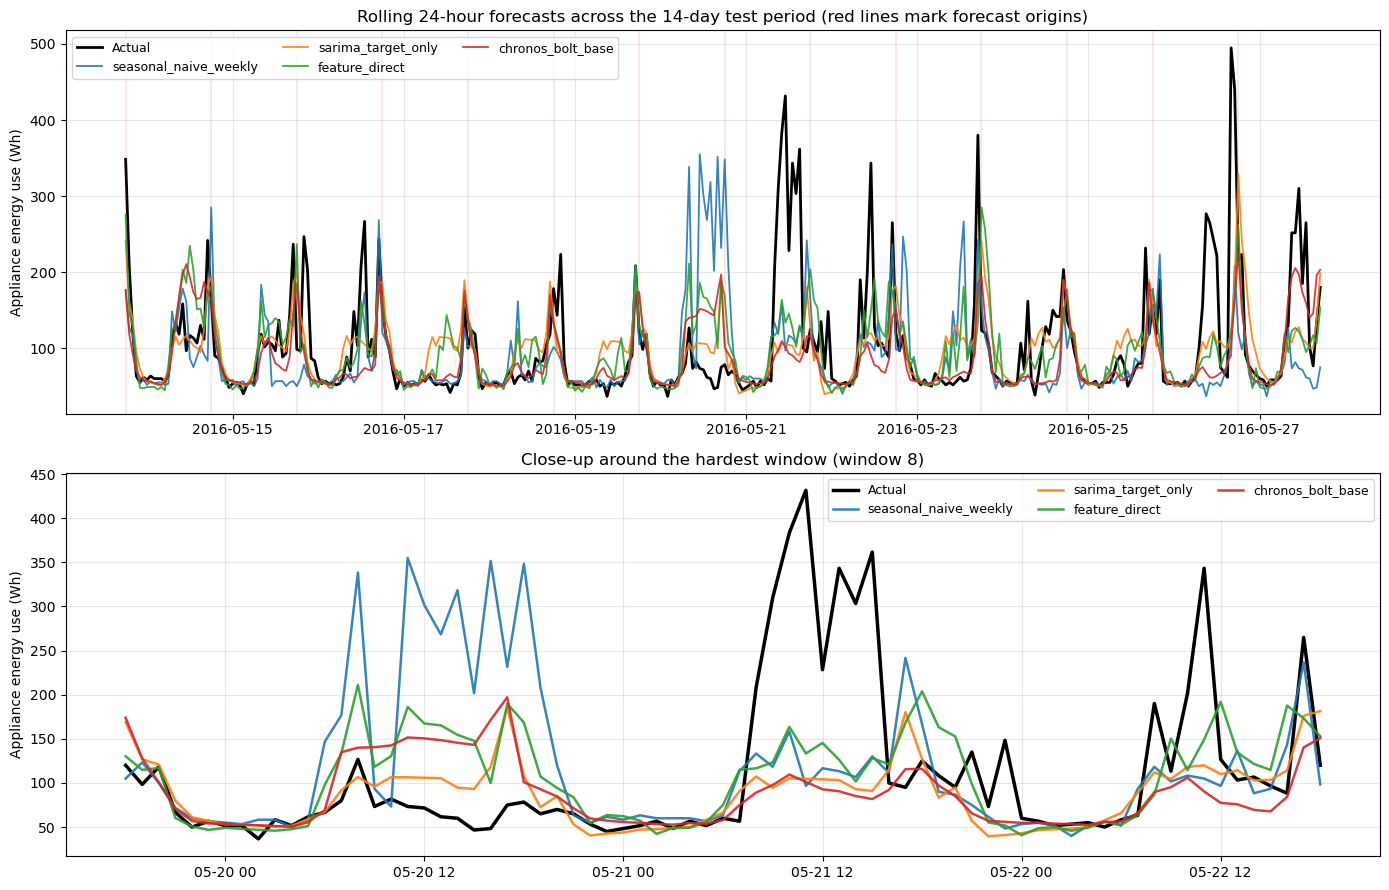

In [12]:

# 12. forecast_comparison.png

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(actual.index, actual.values, color="black", linewidth=2, label="Actual")

palette = plt.cm.tab10(np.linspace(0, 1, 10))

for colour, column in zip(palette, leading_models):
    axes[0].plot(extended.index, extended[column], linewidth=1.3, alpha=0.9,
                 color=colour, label=column)

for w in range(N_WINDOWS):
    axes[0].axvline(actual.index[w * HORIZON], color="tab:red", alpha=0.10)

axes[0].set_title("Rolling 24-hour forecasts across the 14-day test period "
                  "(red lines mark forecast origins)")
axes[0].set_ylabel("Appliance energy use (Wh)")
axes[0].legend(ncol=3, fontsize=9)

# A three-day close-up, including the hardest window.
zoom_start = actual[window == worst_window].index.min() - pd.Timedelta(hours=24)
zoom_end = zoom_start + pd.Timedelta(hours=72)

axes[1].plot(actual.loc[zoom_start:zoom_end].index,
             actual.loc[zoom_start:zoom_end].values,
             color="black", linewidth=2.5, label="Actual")

for colour, column in zip(palette, leading_models):
    series = extended[column].loc[zoom_start:zoom_end]
    axes[1].plot(series.index, series.values, linewidth=1.8, alpha=0.9,
                 color=colour, label=column)

axes[1].set_title(f"Close-up around the hardest window (window {worst_window})")
axes[1].set_ylabel("Appliance energy use (Wh)")
axes[1].legend(ncol=3, fontsize=9)

fig.tight_layout()
save_fig(fig, "forecast_comparison.png")

plt.show()

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\error_diagnostics.png


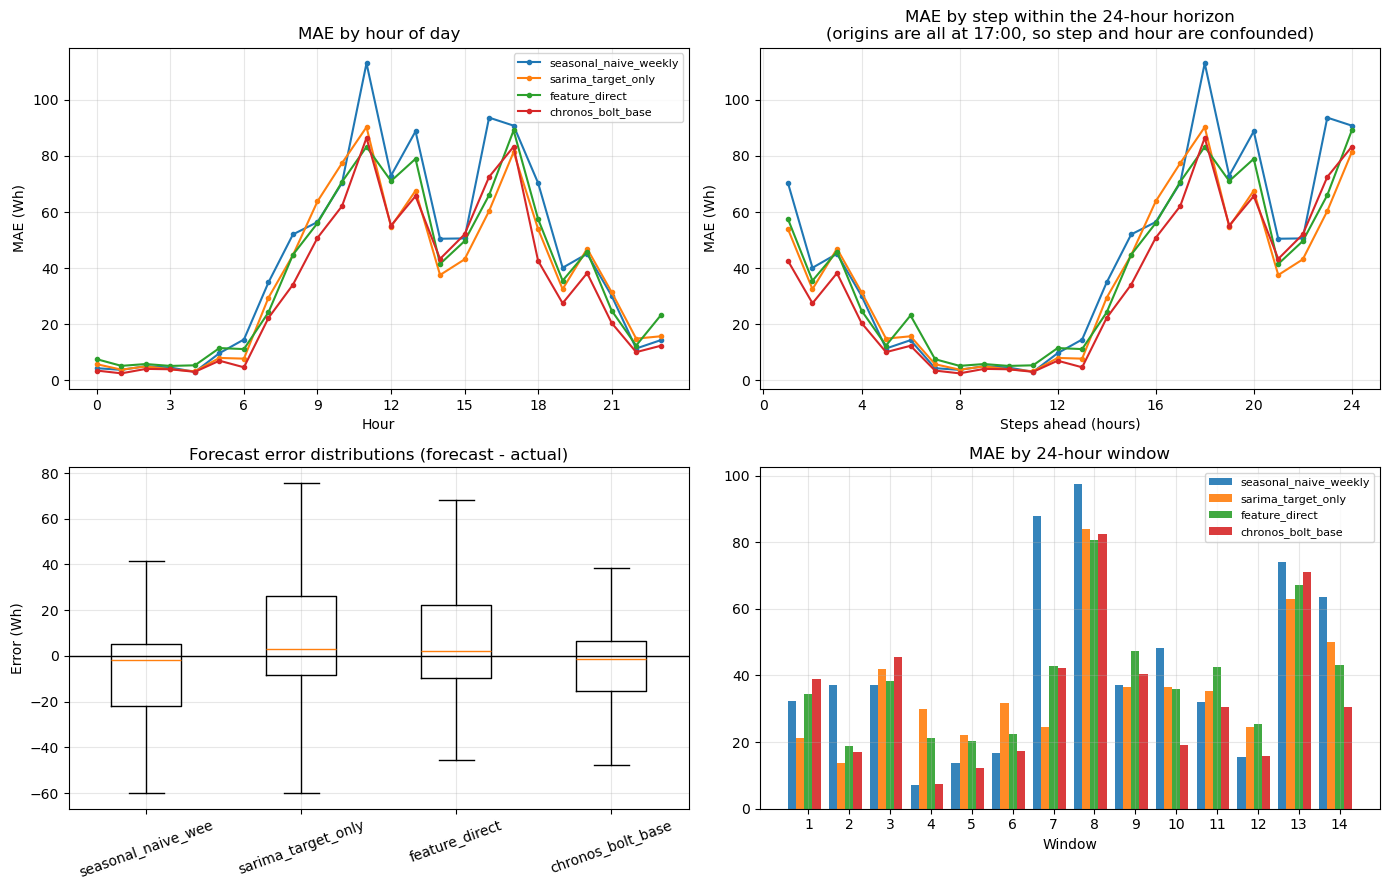

In [13]:

# 13. error_diagnostics.png

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) MAE by hour of day
by_hour = errors.abs().groupby(errors.index.hour).mean()

for column in by_hour.columns:
    axes[0, 0].plot(by_hour.index, by_hour[column], marker="o", markersize=3, label=column)

axes[0, 0].set_title("MAE by hour of day")
axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("MAE (Wh)")
axes[0, 0].set_xticks(range(0, 24, 3))
axes[0, 0].legend(fontsize=8)

# (b) MAE by step within the horizon
by_step = errors.abs().groupby(step).mean()

for column in by_step.columns:
    axes[0, 1].plot(by_step.index, by_step[column], marker="o", markersize=3, label=column)

axes[0, 1].set_title("MAE by step within the 24-hour horizon\n"
                     "(origins are all at 17:00, so step and hour are confounded)")
axes[0, 1].set_xlabel("Steps ahead (hours)")
axes[0, 1].set_ylabel("MAE (Wh)")
axes[0, 1].set_xticks(range(0, 25, 4))

# (c) Error distributions
axes[1, 0].boxplot([errors[c].values for c in errors.columns],
                   tick_labels=[c[:18] for c in errors.columns], showfliers=False)
axes[1, 0].axhline(0, color="black", linewidth=1)
axes[1, 0].set_title("Forecast error distributions (forecast - actual)")
axes[1, 0].set_ylabel("Error (Wh)")
axes[1, 0].tick_params(axis="x", rotation=20)

# (d) MAE by window
x = np.arange(N_WINDOWS)
width = 0.8 / len(leading_models)

for i, column in enumerate(leading_models):
    axes[1, 1].bar(x + i * width - 0.4, per_window_mae[column], width,
                   label=column, alpha=0.9)

axes[1, 1].set_title("MAE by 24-hour window")
axes[1, 1].set_xlabel("Window")
axes[1, 1].set_xticks(x, per_window_mae.index)
axes[1, 1].legend(fontsize=8)

fig.tight_layout()
save_fig(fig, "error_diagnostics.png")

plt.show()

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\residual_acf.png


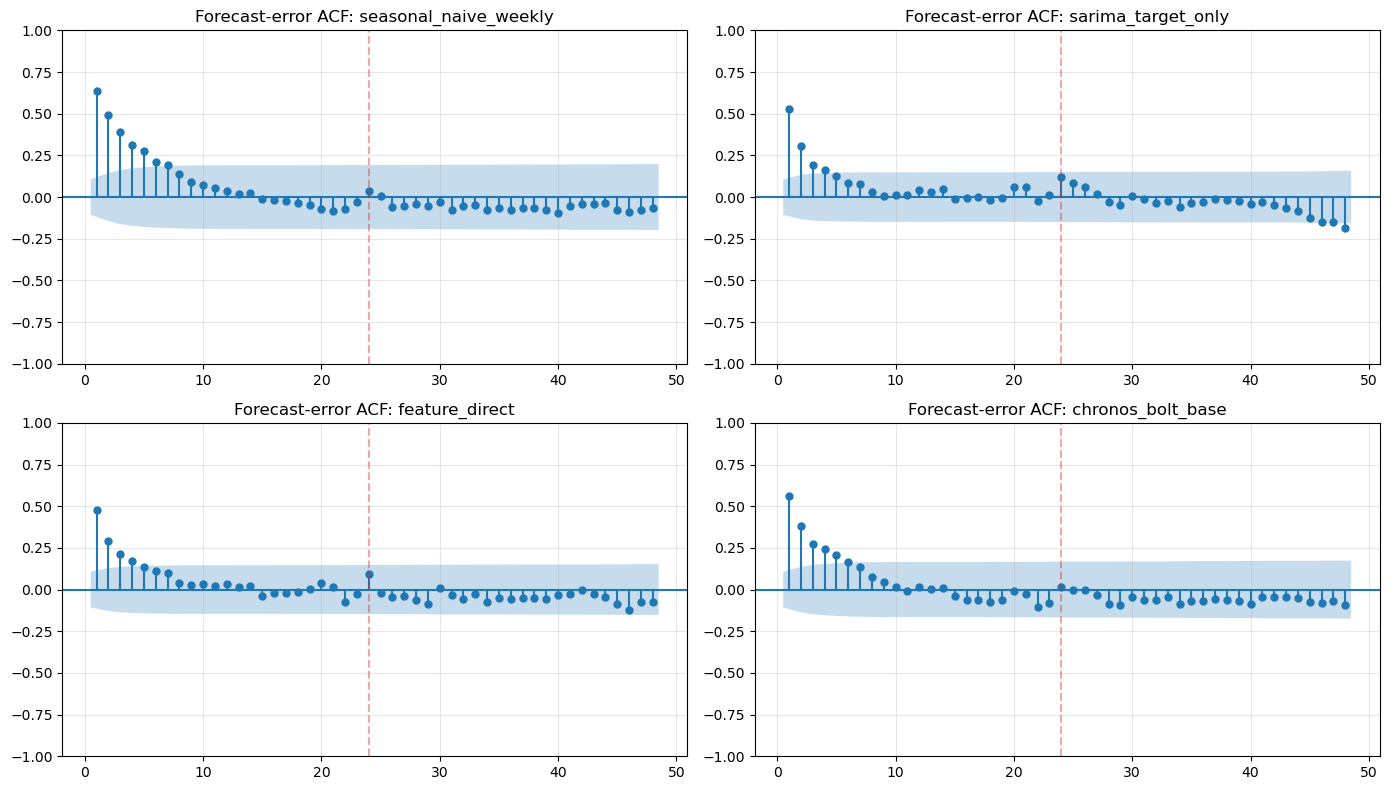

Ljung-Box on the test-period forecast errors:

                model  ljung_box_p_lag24  mean_error  error_sd
seasonal_naive_weekly                0.0    -12.6240   78.7791
   sarima_target_only                0.0     -4.6519   64.1316
       feature_direct                0.0     -3.9474   65.2500
    chronos_bolt_base                0.0    -15.5959   64.2345


In [14]:

# 14. residual_acf.png

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

ljung_rows = []

for ax, column in zip(axes.ravel(), leading_models):
    series = errors[column]

    plot_acf(series.values, lags=48, ax=ax, zero=False)

    ax.set_title(f"Forecast-error ACF: {column}")
    ax.axvline(24, color="tab:red", linestyle="--", alpha=0.4)

    test_result = acorr_ljungbox(series, lags=[24], return_df=True)

    ljung_rows.append({
        "model": column,
        "ljung_box_p_lag24": float(test_result.loc[24, "lb_pvalue"]),
        "mean_error": float(series.mean()),
        "error_sd": float(series.std()),
    })

fig.tight_layout()
save_fig(fig, "residual_acf.png")

plt.show()

print("Ljung-Box on the test-period forecast errors:\n")
print(pd.DataFrame(ljung_rows).round(4).to_string(index=False))

These are *forecast* errors on the test period, not in-sample residuals, so some structure is
expected: within a 24-hour window the model cannot correct itself, and consecutive errors on
a badly-forecast evening will be similar. Autocorrelation that survives at lag 24 is the more
interesting signal, since it points to systematic error at the same hour on consecutive days -
something a model could in principle learn and has not.

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\07_mase_summary.png


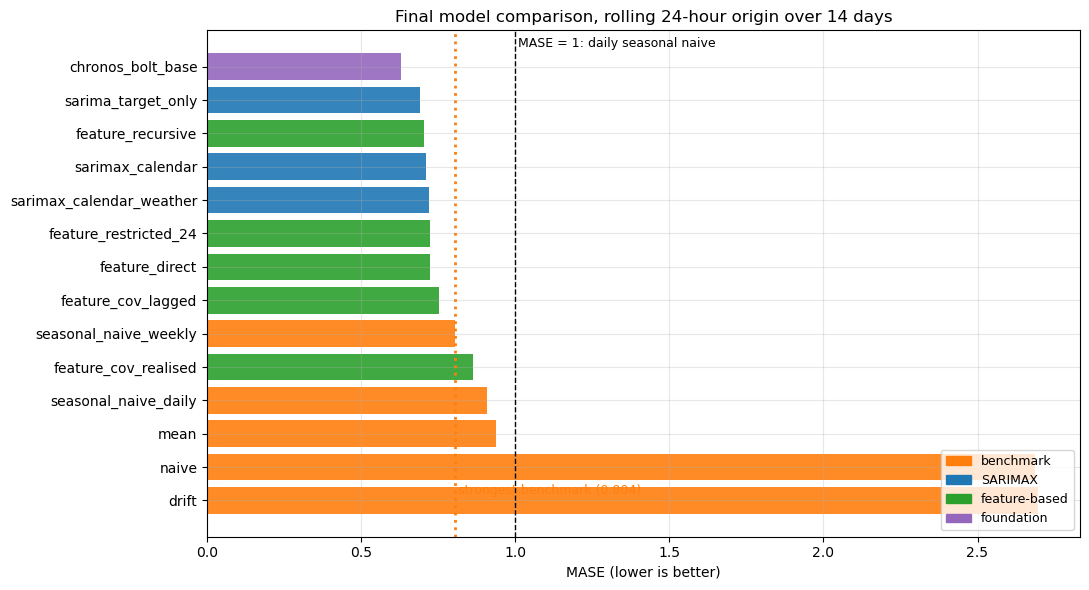

In [15]:

# 15. 07_mase_summary.png

plot_order = comparison_extended.sort_values("MASE", ascending=True)

colours = {
    "benchmark": "tab:orange",
    "SARIMAX": "tab:blue",
    "feature-based": "tab:green",
    "foundation": "tab:purple",
}

fig, ax = plt.subplots(figsize=(11, 6))

bar_colours = [colours.get(c, "tab:grey") for c in plot_order["class"]]

ax.barh(plot_order["model"], plot_order["MASE"], color=bar_colours, alpha=0.9)

ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.text(1.01, -0.6, "MASE = 1: daily seasonal naive", fontsize=9)

ax.axvline(benchmark_mase, color="tab:orange", linestyle=":", linewidth=2)
ax.text(benchmark_mase + 0.01, len(plot_order) - 1.2,
        f"strongest benchmark ({benchmark_mase:.3f})", fontsize=9, color="tab:orange")

ax.invert_yaxis()
ax.set_xlabel("MASE (lower is better)")
ax.set_title("Final model comparison, rolling 24-hour origin over 14 days")

present = [c for c in colours if c in set(plot_order["class"])]

handles = [plt.Rectangle((0, 0), 1, 1, color=colours[c]) for c in present]
ax.legend(handles, present, fontsize=9, loc="lower right")

fig.tight_layout()
save_fig(fig, "07_mase_summary.png")

plt.show()

## 7. Save the final outputs

In [16]:

# 16. Save forecasts and metrics in the schema the README specifies

all_forecasts.to_csv(FORECAST_DIR / "all_forecasts.csv")
extended.to_csv(FORECAST_DIR / "all_forecasts_extended.csv")

canonical_series = [column for _, column in CANONICAL_MAPPING.values()]

model_comparison = (
    comparison_extended
    .loc[comparison_extended["model"].isin(canonical_series),
         ["model", "MAE", "RMSE", "MASE", "Bias"]]
    .sort_values("MASE")
    .reset_index(drop=True)
)

model_comparison.to_csv(METRICS_DIR / "model_comparison.csv", index=False)

comparison_extended.to_csv(METRICS_DIR / "model_comparison_extended.csv", index=False)
significance.to_csv(METRICS_DIR / "pairwise_significance.csv", index=False)

print("model_comparison.csv:\n")
print(model_comparison.round(3).to_string(index=False))

print()
for path in [FORECAST_DIR / "all_forecasts.csv",
             FORECAST_DIR / "all_forecasts_extended.csv",
             METRICS_DIR / "model_comparison.csv",
             METRICS_DIR / "model_comparison_extended.csv",
             METRICS_DIR / "pairwise_significance.csv"]:
    print("Saved:", path.relative_to(PROJECT_ROOT))

model_comparison.csv:

                model     MAE    RMSE  MASE    Bias
    chronos_bolt_base  33.629  66.008 0.630 -15.596
   sarima_target_only  36.785  64.205 0.689  -4.652
       feature_direct  38.585  65.272 0.723  -3.947
seasonal_naive_weekly  42.922  79.668 0.804 -12.624
 seasonal_naive_daily  48.393  85.790 0.907   1.667
                 mean  50.010  73.986 0.937  -3.061
                naive 143.383 170.623 2.687 114.673
                drift 143.942 171.260 2.698 115.314

Saved: outputs\forecasts\all_forecasts.csv
Saved: outputs\forecasts\all_forecasts_extended.csv
Saved: outputs\metrics\model_comparison.csv
Saved: outputs\metrics\model_comparison_extended.csv
Saved: outputs\metrics\pairwise_significance.csv


In [17]:

# 17. Verify the saved outputs against the README schema

REQUIRED_FORECAST_COLUMNS = [
    "actual", "mean", "naive", "seasonal_naive_daily", "seasonal_naive_weekly",
    "drift", "sarimax", "feature_model", "foundation_model",
]

REQUIRED_METRIC_COLUMNS = ["model", "MAE", "RMSE", "MASE", "Bias"]

reloaded_forecasts = pd.read_csv(
    FORECAST_DIR / "all_forecasts.csv", index_col=0, parse_dates=True
)

reloaded_metrics = pd.read_csv(METRICS_DIR / "model_comparison.csv")

assert list(reloaded_forecasts.columns) == REQUIRED_FORECAST_COLUMNS, \
    f"Schema mismatch: {list(reloaded_forecasts.columns)}"
assert list(reloaded_metrics.columns) == REQUIRED_METRIC_COLUMNS
assert len(reloaded_forecasts) == TEST_STEPS
assert reloaded_forecasts.isna().sum().sum() == 0
assert reloaded_forecasts.index.equals(actual.index)

# A perfect forecast must score zero on every metric.
perfect = evaluate_forecast("perfect", actual, actual)
assert all(np.isclose(perfect[m], 0.0) for m in ["MAE", "RMSE", "MASE", "Bias"])

print("All outputs verified against the README schema.")
print("Forecast columns:", list(reloaded_forecasts.columns))
print("Metric columns:", list(reloaded_metrics.columns))
print("Rows:", len(reloaded_forecasts))

All outputs verified against the README schema.
Forecast columns: ['actual', 'mean', 'naive', 'seasonal_naive_daily', 'seasonal_naive_weekly', 'drift', 'sarimax', 'feature_model', 'foundation_model']
Metric columns: ['model', 'MAE', 'RMSE', 'MASE', 'Bias']
Rows: 336
